# Full selfconsistency with all Wick terms for non-collinear superconductors

`get_combined_mean_field_hamiltonian` decouples density-density ($V_1$) and spin-spin exchange
($J$) channels together with the full normal-plus-anomalous Hartree-Fock-Bogoliubov treatment on a
Nambu Hamiltonian, so an antiferromagnetic exchange can spontaneously generate singlet pairing (the
same RVB-like mechanism behind exchange-driven superconductivity) at the same time as an attractive
$V_1$ promotes its own pairing channel -- all Wick contractions (normal collinear, normal
non-collinear, and anomalous) are solved in the same selfconsistency loop.

Identified symmetry breaking: ['magnetic', 'ferroZ', 'dx SC', 'dy SC', 'up-up pairing', 'down-down pairing', 'Non-unitary superconductivity', 'Spin-triplet superconductivity']


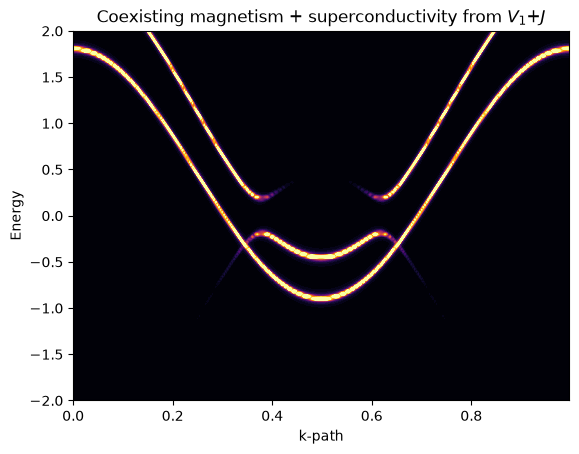

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import meanfield

g = geometry.chain()
h = g.get_hamiltonian(has_spin=True)
h.add_exchange([0.,0.,0.3]) # seed a small persistent exchange field
h.turn_nambu()
scf = meanfield.VJinteraction(h,V1=-1.0,J1z=-0.3,filling=0.3,mf="random")

print("Identified symmetry breaking:",scf.identify_symmetry_breaking())
hscf = scf.hamiltonian

es = np.linspace(-2.0,2.0,150)
nk = 300
kx,ky,d = hscf.get_kdos_bands(operator="electron",nk=nk,energies=es)
dgrid = d.reshape(nk,len(es)).T
plt.contourf(np.unique(kx),es,dgrid,levels=100,cmap="inferno",vmax=np.percentile(dgrid,99))
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("Coexisting magnetism + superconductivity from $V_1$+$J$")
plt.show()